In [1]:
from utils import DATA_DIR, select_gpu
import pickle
import torch
import matplotlib.pyplot as plt
import numpy as np

select_gpu()
error_dir = DATA_DIR/"tensors/fineweb_large/decomposition/"
def visualize_errors(method, dims, rank, n_iter):
    try:
        filename = f"errors_{method}_{dims}d_{rank}r_{n_iter}i.pkl"
        with open(error_dir/filename, "rb") as f:
            errors = pickle.load(f)
    except FileNotFoundError:
        filename = f"{method}_{dims}d_{rank}r_{n_iter}i_errors.npy"
        errors = np.load(error_dir/filename)
    errors_float = [float(e) for e in errors]
    plt.plot(errors_float)
    plt.title(f"Errors for {method}: dims={dims}, rank={rank}, n_iter={n_iter}")
    plt.xlabel("Iteration")
    plt.ylabel("Reconstruction Error")
    plt.show()


Selected GPU 0 with 3218.00 MB used memory.


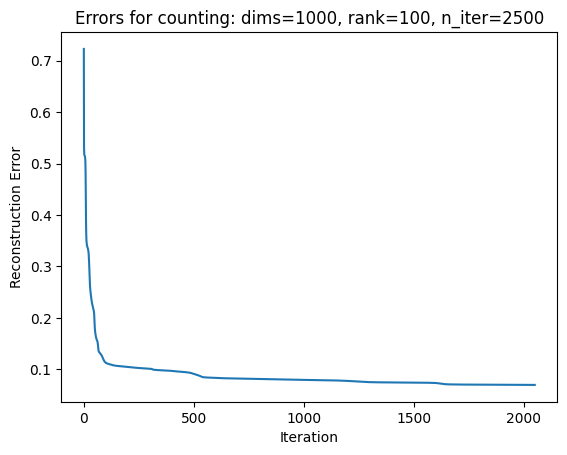

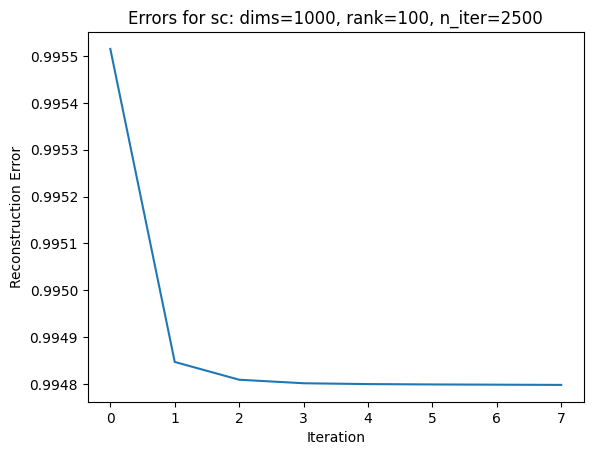

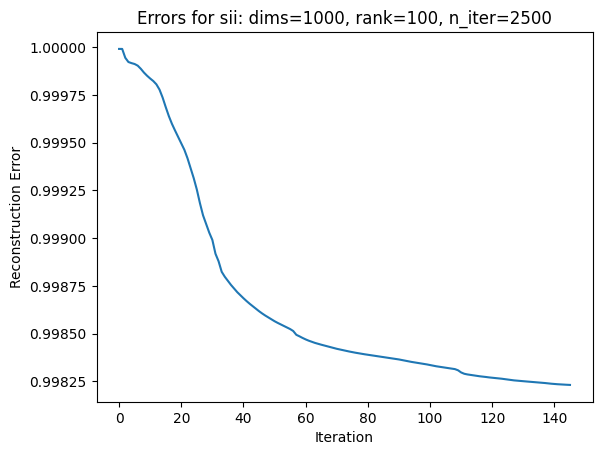

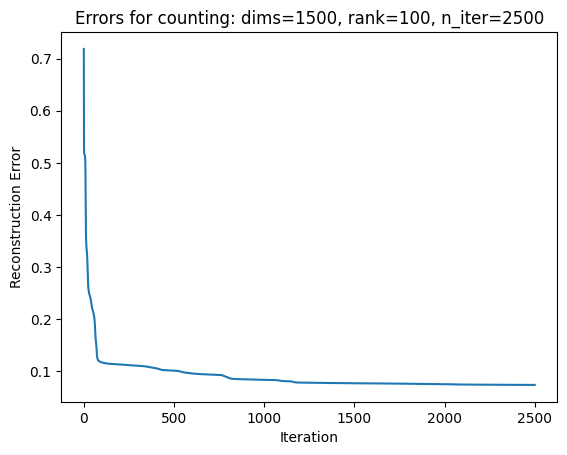

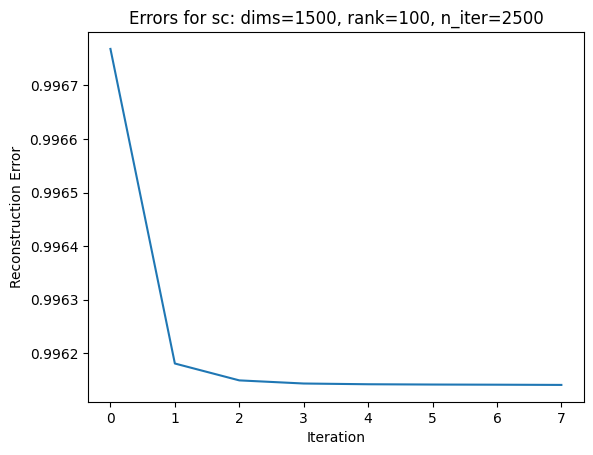

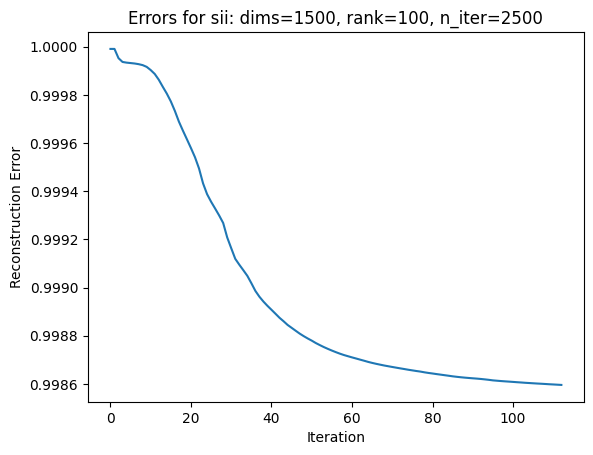

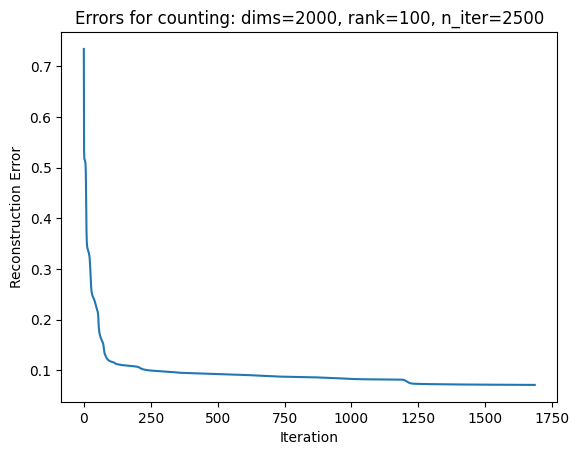

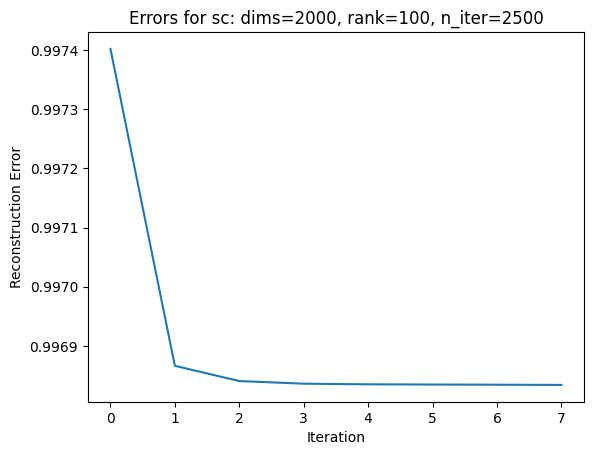

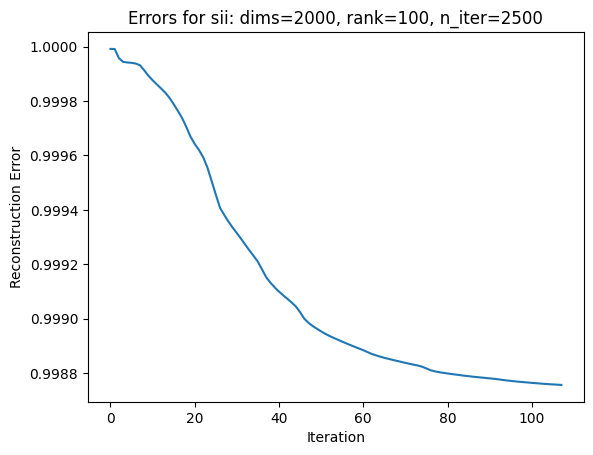

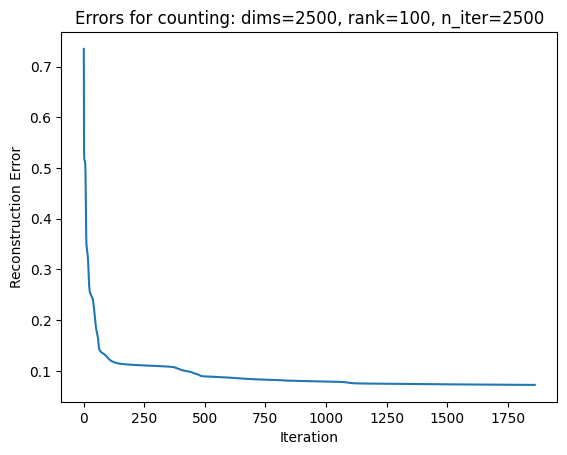

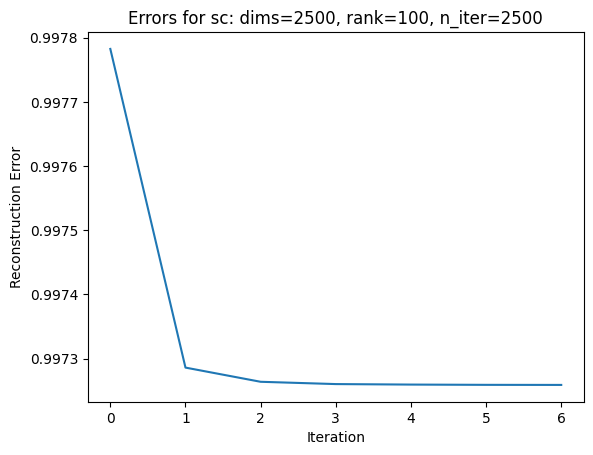

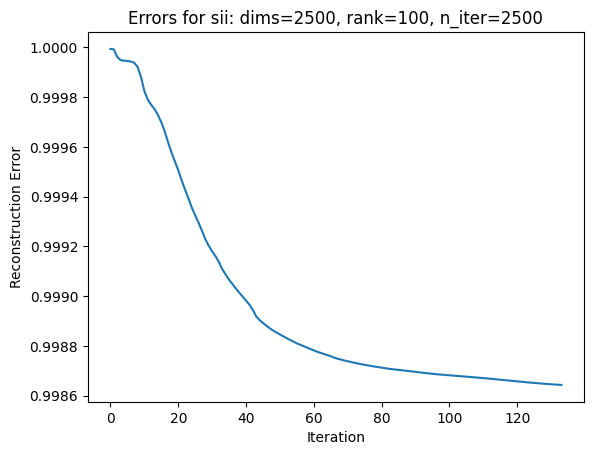

In [2]:
methods = ["counting", "sc", "sii"]
dims = [1000, 1500, 2000, 2500]
rank = 100
n_iter = 2500
for d in dims:
    for method in methods:
        visualize_errors(method, d, rank, n_iter)

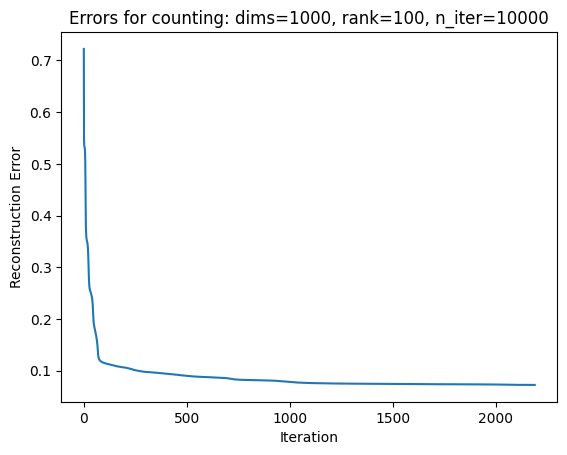

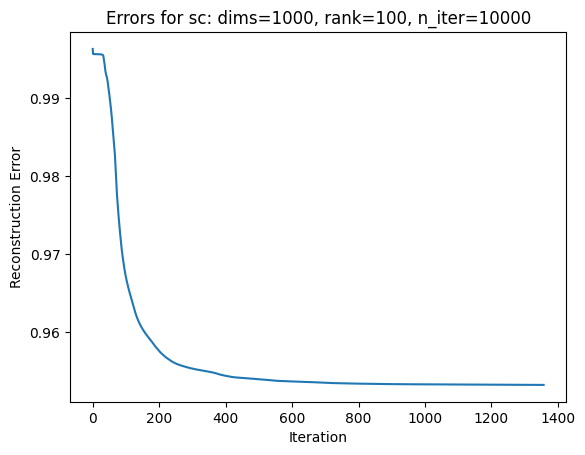

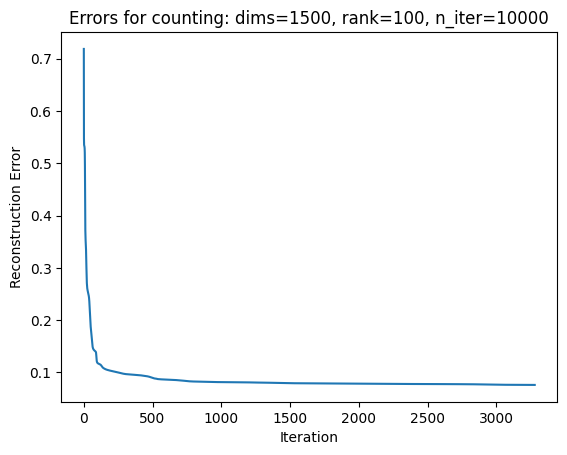

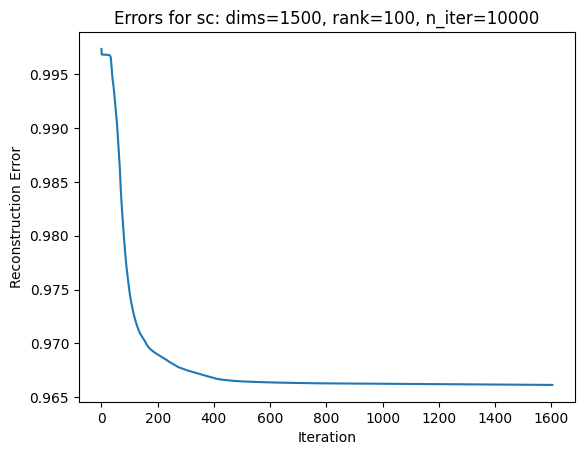

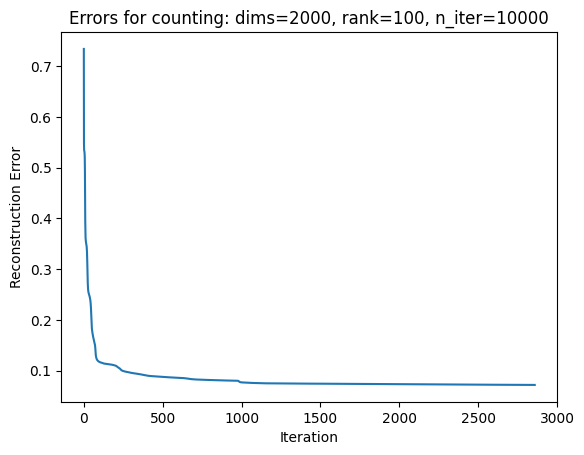

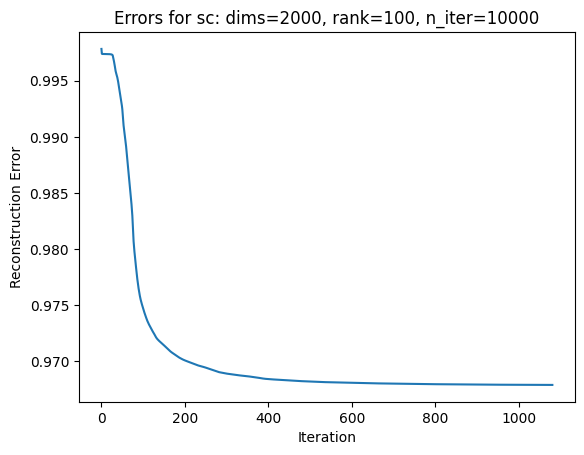

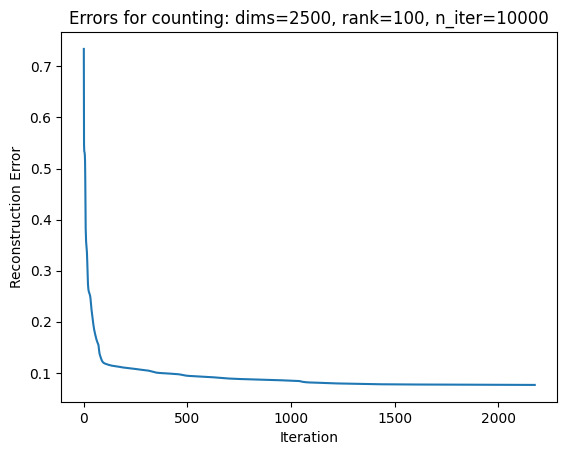

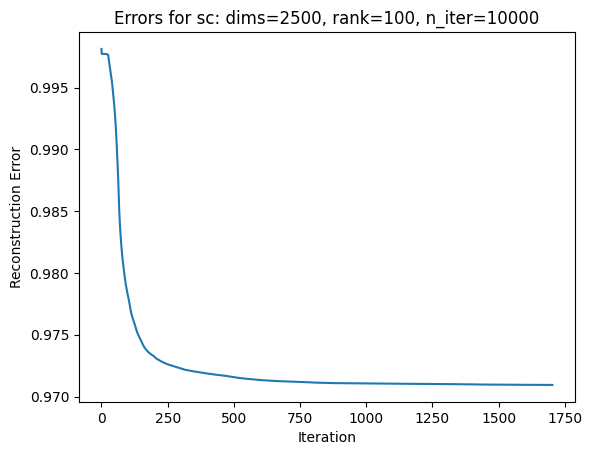

In [4]:
error_dir = DATA_DIR/"tensors/fineweb_sparse/decomposition/"
methods = ["counting", "sc"]
dims = [1000, 1500, 2000, 2500]
rank = 100
n_iter = 10000
for d in dims:
    for method in methods:
        visualize_errors(method, d, rank, n_iter)

In [4]:
# we visualize the errors of the different methods together
def visualize_dim(dims, rank, n_iter):
    methods = ["counting", "sc", "sii"]
    for method in methods:
        filename = f"{method}_{dims}d_{rank}r_{n_iter}i_errors.npy"
        errors = np.load(error_dir/filename)
        errors_float = [float(e) for e in errors]
        plt.plot(errors_float)
    plt.legend(methods)
    plt.title(f"Errors for dims={dims}, rank={rank}, n_iter={n_iter}")
    plt.xlabel("Iteration")
    plt.ylabel("Reconstruction Error")
    plt.show()
def visualize_method(method, rank, n_iter):
    dims = [1000,1500, 2000,2500]
    for dim in dims:
        filename = f"{method}_{dim}d_{rank}r_{n_iter}i_errors.npy"
        errors = np.load(error_dir/filename)
        errors_float = [float(e) for e in errors]
        plt.plot(errors_float)
    # we add a legend
    plt.legend(dims)
    plt.title(f"Errors for {method} (dims={dim}, rank={rank}, n_iter={n_iter})")
    plt.xlabel("Iteration")
    plt.ylabel("Reconstruction Error")
    plt.show()


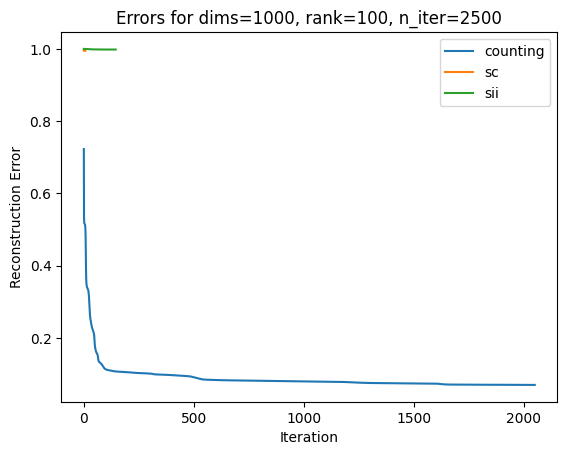

In [6]:
visualize_dim(1000, 100, 2500)

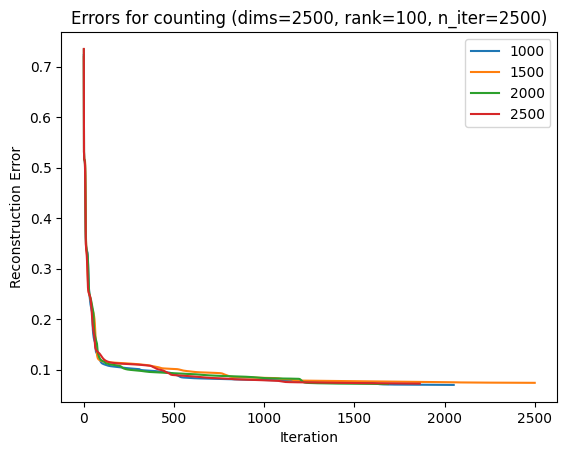

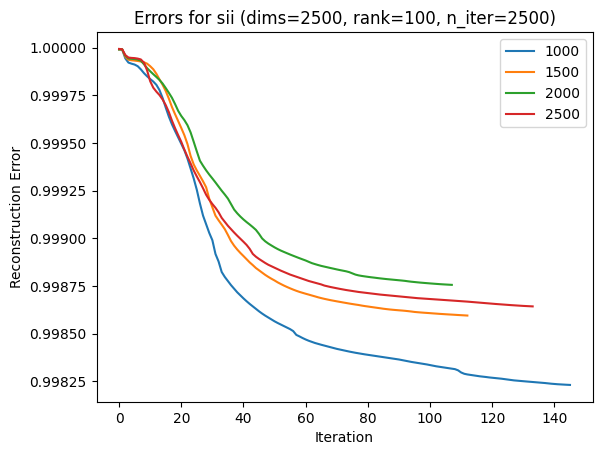

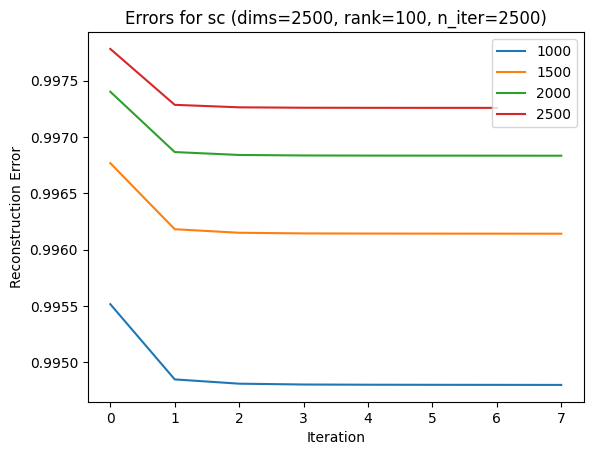

In [7]:
visualize_method("counting", 100, 2500)
visualize_method("sii", 100, 2500)
visualize_method("sc", 100, 2500)


# Semantic error comparation

In [2]:
import pathlib
import os
from tensormet.utils import DATA_DIR
from tensormet.tucker_tensor import TuckerDecomposition

# we check which models are available
goal_path = DATA_DIR / "tensors" / "fineweb-en" / "decomposition"
to_compare = []
for filename in os.listdir(goal_path):
    print(filename)
    if filename.endswith("_fitness.npy"):
        to_compare.append(filename)


fr_counting_1000d_150r_500i_config.json
fr_counting_1000d_150r_500i.pt
fr_counting_1000d_150r_500i_errors.npy
fr_counting_1000d_150r_500i_fitness.npy
runs.jsonl
fr_siiSoftPlus_1000d_150r_500i_config.json
fr_siiSoftPlus_1000d_150r_500i.pt
fr_siiSoftPlus_1000d_150r_500i_errors.npy
fr_siiSoftPlus_1000d_150r_500i_fitness.npy
fr_siiShifted_1000d_150r_500i_config.json
fr_siiShifted_1000d_150r_500i.pt
fr_siiShifted_1000d_150r_500i_errors.npy
fr_siiShifted_1000d_150r_500i_fitness.npy
fr_scSoftPlus_1000d_150r_500i_config.json
fr_scSoftPlus_1000d_150r_500i.pt
fr_scSoftPlus_1000d_150r_500i_errors.npy
fr_scSoftPlus_1000d_150r_500i_fitness.npy
fr_scShifted_1000d_150r_500i_config.json
fr_scShifted_1000d_150r_500i.pt
fr_scShifted_1000d_150r_500i_errors.npy
fr_scShifted_1000d_150r_500i_fitness.npy
kl_counting_1000d_150r_500i_config.json
kl_counting_1000d_150r_500i.pt
kl_counting_1000d_150r_500i_errors.npy
kl_counting_1000d_150r_500i_fitness.npy
kl_siiSoftPlus_1000d_150r_500i_config.json
kl_siiSoftPlus

In [5]:
np.load("fr_counting_1000d_150r_500i_fitness.npy")

FileNotFoundError: [Errno 2] No such file or directory: 'fr_counting_1000d_150r_500i_fitness.npy'

In [11]:
from collections import defaultdict
sorted = defaultdict(list)
for filename in to_compare:
    parts = filename.split("_")
    sorted[(parts[0], parts[1])].append(filename)
sorted

defaultdict(list,
            {('fr', 'counting'): ['fr_counting_1000d_150r_500i_fitness.npy',
              'fr_counting_2000d_150r_500i_fitness.npy'],
             ('fr',
              'siiSoftPlus'): ['fr_siiSoftPlus_1000d_150r_500i_fitness.npy', 'fr_siiSoftPlus_2000d_150r_500i_fitness.npy'],
             ('fr',
              'siiShifted'): ['fr_siiShifted_1000d_150r_500i_fitness.npy', 'fr_siiShifted_2000d_150r_500i_fitness.npy'],
             ('fr',
              'scSoftPlus'): ['fr_scSoftPlus_1000d_150r_500i_fitness.npy', 'fr_scSoftPlus_2000d_150r_500i_fitness.npy'],
             ('fr', 'scShifted'): ['fr_scShifted_1000d_150r_500i_fitness.npy',
              'fr_scShifted_2000d_150r_500i_fitness.npy'],
             ('kl', 'counting'): ['kl_counting_1000d_150r_500i_fitness.npy',
              'kl_counting_2000d_150r_500i_fitness.npy'],
             ('kl',
              'siiSoftPlus'): ['kl_siiSoftPlus_1000d_150r_500i_fitness.npy', 'kl_siiSoftPlus_2000d_150r_500i_fitness.npy'],
    

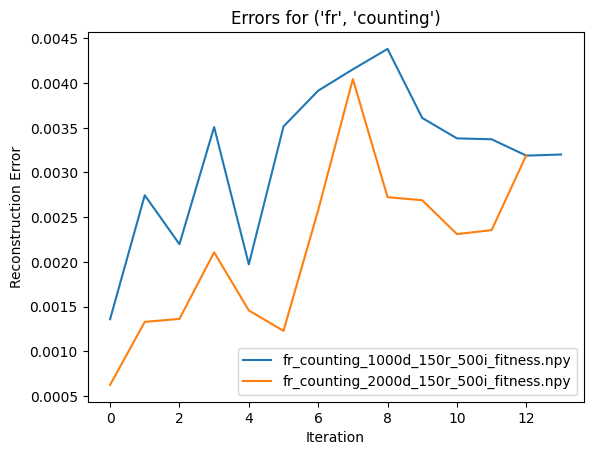

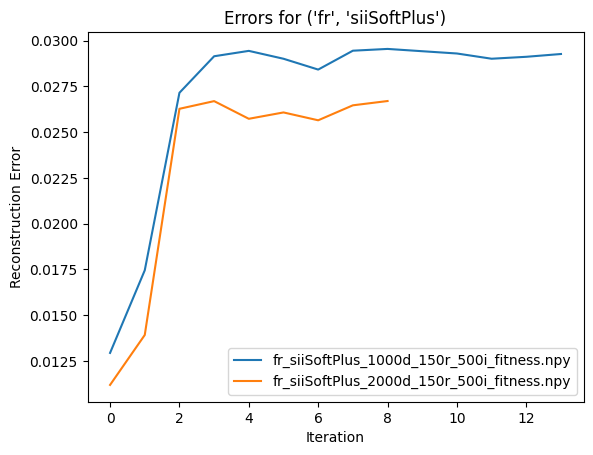

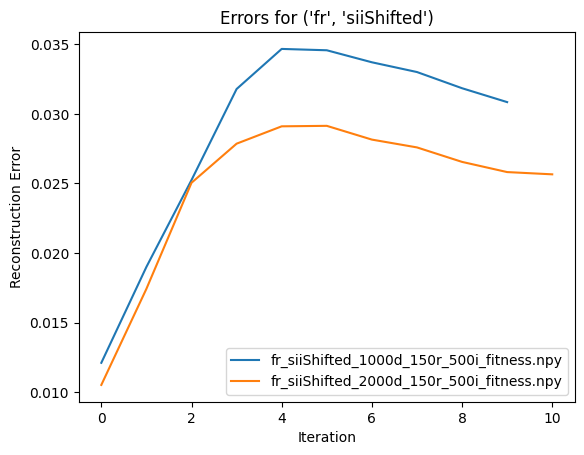

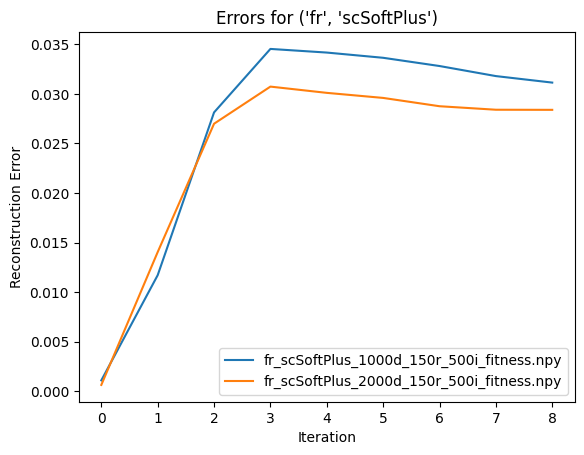

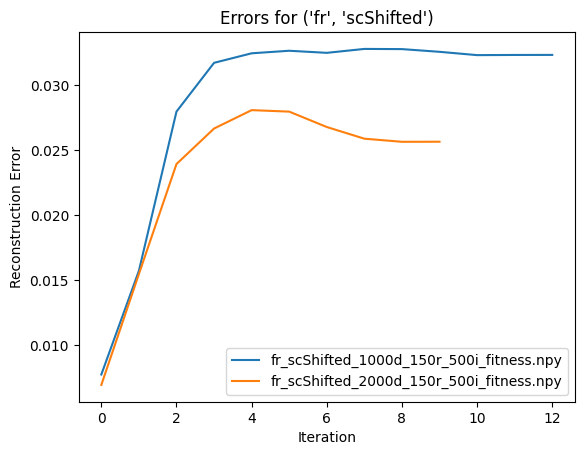

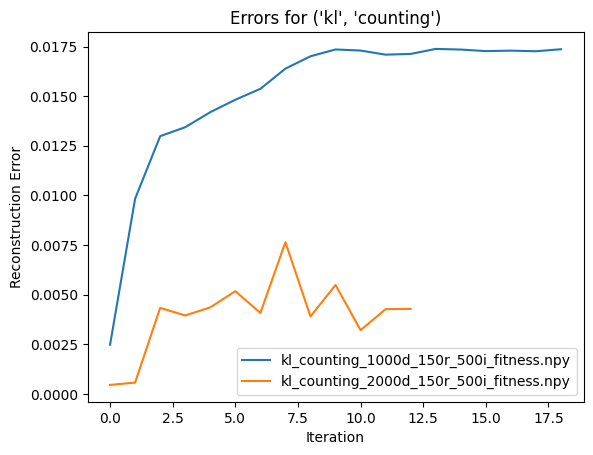

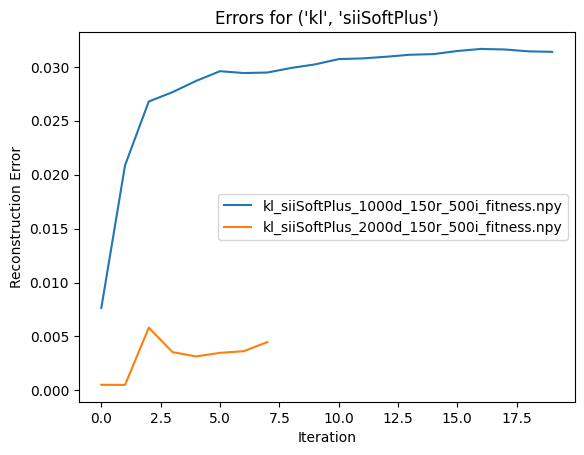

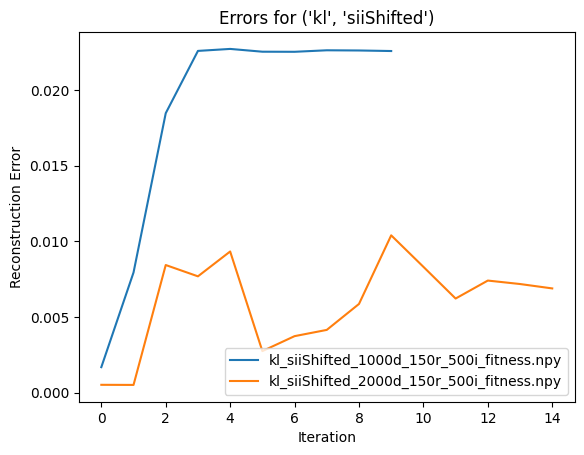

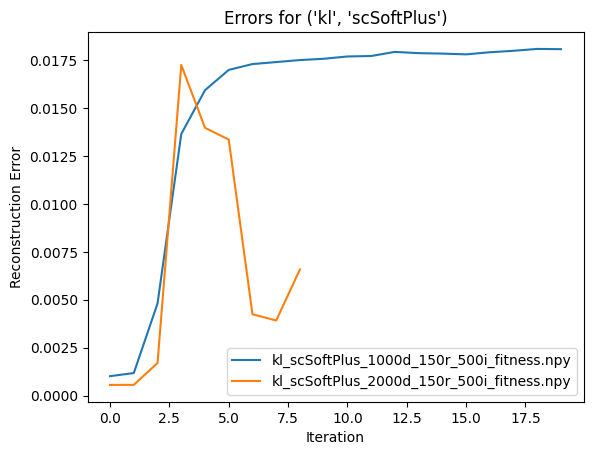

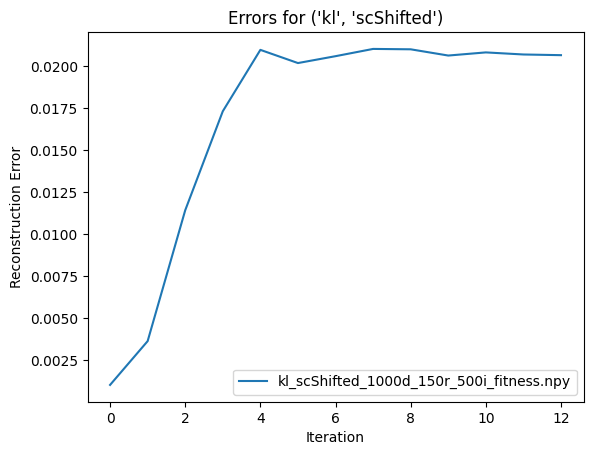

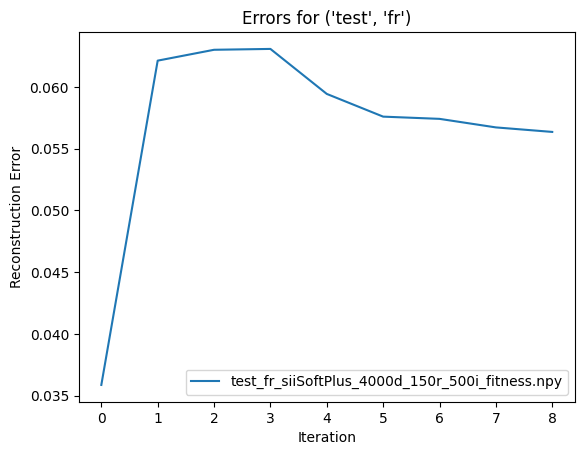

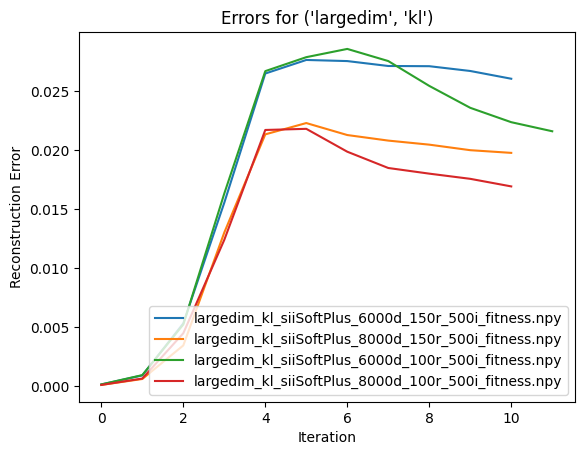

In [12]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

for group, filenames in sorted.items():
    for filename in filenames:
        try:
            errors = np.load(goal_path/filename)
            errors_float = [float(e) for e in errors]
            plt.plot(errors_float)

        except:
            print("error with", filename)
    plt.legend(filenames)
    plt.title(f"Errors for {group}")
    plt.xlabel("Iteration")
    plt.ylabel("Reconstruction Error")
    plt.show()